# Segmentation + skills library building

## Init

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, accuracy_score
import datetime as dt

# from scipy import signal
from scipy.interpolate import make_splrep
import os
from pathlib import Path
from tqdm.auto import tqdm
from pprint import pprint
import ruptures as rpt
from movement_primitives.dmp import DMPWithFinalVelocity

In [2]:
from segmentation_utils import (
    # extract_eef_data_from_rosbag,
    get_ground_truth_segmentation,
    # get_bagfiles_from_json,
    read_h5_data,
    get_gtdict_filenames,
    ts2df,
)

In [3]:
from LfD_Library.MP_Library import gen_traj, MP_Library
from LfD_Library.sim_metrics import *
from ElasticMaps.elmap_EM import ElmapEM

In [4]:
# %matplotlib ipympl
%load_ext autoreload
%autoreload 2

## Data files

In [5]:
# data_path_root = Path("../table-task-ur5e")
data_path_root = Path(".") / "data"
data_path_root.exists()

True

In [6]:
ground_truth_segm_file = Path(".") / "segm_ground_truth.json"
ground_truth_segm_file.exists()

True

In [7]:
# bagfiles = get_bagfiles_from_json(ground_truth_segm_file=ground_truth_segm_file)
# bagfiles

In [8]:
filenum = 0
# bagfile = bagfiles[filenum]
# bagfile

In [9]:
gt_segm_dict, video_file, hdf5_file = get_gtdict_filenames(
    ground_truth_segm_file=ground_truth_segm_file, filenum=filenum
)
pprint(gt_segm_dict)

{'hdf5': 'long-task-1.h5',
 'segments': {'close-drawer': {'end': 1769723279, 'ini': 1769723262},
              'open-drawer': {'end': 1769723235, 'ini': 1769723216},
              'pick&place': [{'end': 1769723248, 'ini': 1769723235},
                             {'end': 1769723262, 'ini': 1769723248}],
              'pour': {'end': 1769723311, 'ini': 1769723279}},
 'synchro_ts': 2067,
 'synchro_vid': 2036,
 'video': 'long-task-1.MOV'}


In [10]:
hdf5_path = data_path_root / hdf5_file
video_path = data_path_root / video_file

## Preprocessing

In [11]:
joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=hdf5_path)

['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


In [12]:
# traj = extract_eef_data_from_rosbag(bagfile)
traj = ts2df(tf_data=tf_data, gripper_data=gripper_data)
traj

,x,y,z,timestamp,gripper
0,0.133347,-0.491981,0.488070,2026-01-29 16:46:49.273737185-05:00,0.01
1,0.133354,-0.491975,0.488080,2026-01-29 16:46:49.275736664-05:00,0.01
2,0.133358,-0.491972,0.488044,2026-01-29 16:46:49.277680340-05:00,0.01
3,0.133351,-0.491997,0.488007,2026-01-29 16:46:49.279664024-05:00,0.01
4,0.133328,-0.491981,0.488071,2026-01-29 16:46:49.281634923-05:00,0.01
...,...,...,...,...,...
53132,-0.061511,-0.594210,0.273193,2026-01-29 16:48:36.122627710-05:00,0.01
53133,-0.061486,-0.594203,0.273203,2026-01-29 16:48:36.124703544-05:00,0.01
53134,-0.061480,-0.594227,0.273175,2026-01-29 16:48:36.126640743-05:00,0.01
53135,-0.061488,-0.594235,0.273185,2026-01-29 16:48:36.128663112-05:00,0.01


In [13]:
# df = traj.diff().mean().timestamp.total_seconds()
# df

In [14]:
# downsampling = 10

In [15]:
# freq = 1 / (df * downsampling)
# freq

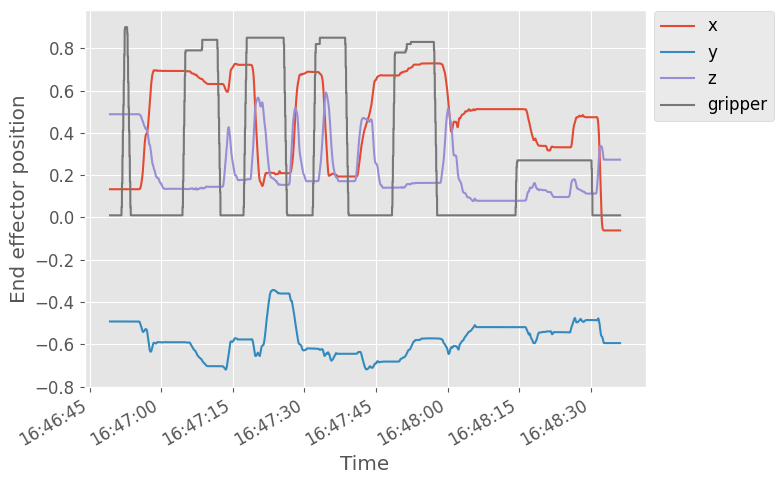

In [16]:
with plt.style.context("ggplot_perso.mplstyle"):
    # with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(8, 5))
    # cmap = mpl.colormaps.get("tab10").colors
    ax.plot(traj.timestamp, traj.x, label="x")  # , color=cmap[0])
    ax.plot(traj.timestamp, traj.y, label="y")  # , color=cmap[1])
    ax.plot(traj.timestamp, traj.z, label="z")  # , color=cmap[2])
    ax.plot(traj.timestamp, traj.gripper, label="gripper")  # , color=cmap[3])
    ax.set_xlabel("Time")
    ax.set_ylabel("End effector position")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## Ground truth segmentation

In [17]:
# gt_segm_dict = get_ground_truth_segmentation(
#     ground_truth_segm_file=ground_truth_segm_file, bagfile=bagfile
# )
# pprint(gt_segm_dict)

### Adding more features: objects moving

In [18]:
nsegments = 0
obj_labels = []
for segm_key, segm_val in gt_segm_dict["segments"].items():
    if isinstance(segm_val, list):
        nsegments += len(segm_val)
        for jdx, _ in enumerate(segm_val):
            obj_labels.append(f"{segm_key}-{jdx + 1}")
    elif isinstance(segm_val, dict):
        nsegments += 1
        obj_labels.append(segm_key)
    else:
        raise ValueError("Unexpected value in ground truth JSON file")
nsegments, obj_labels

(5, ['open-drawer', 'pick&place-1', 'pick&place-2', 'close-drawer', 'pour'])

In [19]:
objects = np.zeros((traj.shape[0], nsegments))
objects.shape

(53137, 5)

In [20]:
col_i = 0
for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
    sect_dict_current = gt_segm_dict["segments"][sect_key]
    if isinstance(sect_dict_current, list):
        for sect_j, sect_cur in enumerate(sect_dict_current):
            xs = traj.timestamp[
                (
                    traj.timestamp
                    > pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_cur["ini"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
                & (
                    traj.timestamp
                    < pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_cur["end"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
            ]
            print(col_i)
            objects[xs.index, col_i] = np.ones_like(xs)
            col_i += 1

    elif isinstance(sect_dict_current, dict):
        xs = traj.timestamp[
            (
                traj.timestamp
                > pd.Timestamp(
                    dt.datetime.fromtimestamp(sect_dict_current["ini"]),
                    # - dt.timedelta(hours=1),
                    tz="EST",
                )
            )
            & (
                traj.timestamp
                < pd.Timestamp(
                    dt.datetime.fromtimestamp(sect_dict_current["end"]),
                    # - dt.timedelta(hours=1),
                    tz="EST",
                )
            )
        ]
        print(col_i)
        objects[xs.index, col_i] = np.ones_like(xs)
        col_i += 1
    else:
        raise ValueError("Unexpected value in ground truth JSON file")

objects

0
1
2
3
4


array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], shape=(53137, 5))

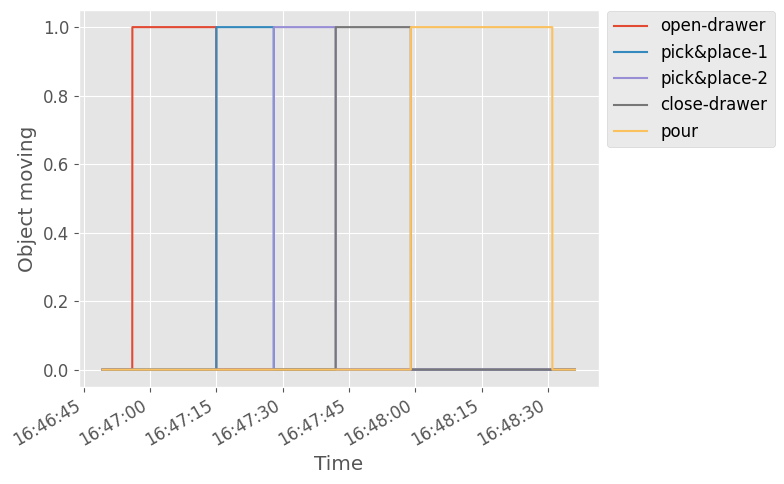

In [21]:
with plt.style.context("ggplot_perso.mplstyle"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for idx in range(objects.shape[1]):
        ax.plot(
            traj.timestamp,
            objects[:, idx],
            label=obj_labels[idx],
        )
    ax.set_xlabel("Time")
    ax.set_ylabel("Object moving")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

In [22]:
for idx in range(objects.shape[1]):
    traj[obj_labels[idx]] = objects[:, idx]
traj

,x,y,z,timestamp,gripper,open-drawer,pick&place-1,pick&place-2,close-drawer,pour
0,0.133347,-0.491981,0.488070,2026-01-29 16:46:49.273737185-05:00,0.01,0.0,0.0,0.0,0.0,0.0
1,0.133354,-0.491975,0.488080,2026-01-29 16:46:49.275736664-05:00,0.01,0.0,0.0,0.0,0.0,0.0
2,0.133358,-0.491972,0.488044,2026-01-29 16:46:49.277680340-05:00,0.01,0.0,0.0,0.0,0.0,0.0
3,0.133351,-0.491997,0.488007,2026-01-29 16:46:49.279664024-05:00,0.01,0.0,0.0,0.0,0.0,0.0
4,0.133328,-0.491981,0.488071,2026-01-29 16:46:49.281634923-05:00,0.01,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
53132,-0.061511,-0.594210,0.273193,2026-01-29 16:48:36.122627710-05:00,0.01,0.0,0.0,0.0,0.0,0.0
53133,-0.061486,-0.594203,0.273203,2026-01-29 16:48:36.124703544-05:00,0.01,0.0,0.0,0.0,0.0,0.0
53134,-0.061480,-0.594227,0.273175,2026-01-29 16:48:36.126640743-05:00,0.01,0.0,0.0,0.0,0.0,0.0
53135,-0.061488,-0.594235,0.273185,2026-01-29 16:48:36.128663112-05:00,0.01,0.0,0.0,0.0,0.0,0.0


In [23]:
# def add_more_features(ground_truth_segm_file, bagfile, traj):
#     # Get the ground truth data for the BAG file
#     gt_segm_dict = get_ground_truth_segmentation(
#         ground_truth_segm_file=ground_truth_segm_file, bagfile=bagfile
#     )

#     # Initialize the matrix
#     objects = np.zeros((traj.shape[0], len(gt_segm_dict["HigherLevel"].keys())))

#     # Set to ones for each object when it's moving
#     for sect_i, sect_key in enumerate(gt_segm_dict["HigherLevel"].keys()):
#         sect_dict_current = gt_segm_dict["HigherLevel"][sect_key]
#         xs = traj.timestamp[
#             (
#                 traj.timestamp
#                 > pd.Timestamp(
#                     dt.datetime.fromtimestamp(sect_dict_current["ini"])
#                     - dt.timedelta(hours=1),
#                     tz="EST",
#                 )
#             )
#             & (
#                 traj.timestamp
#                 < pd.Timestamp(
#                     dt.datetime.fromtimestamp(sect_dict_current["end"])
#                     - dt.timedelta(hours=1),
#                     tz="EST",
#                 )
#             )
#         ]
#         objects[xs.index, sect_i] = np.ones_like(xs)

#     # Merge with the original DataFrame
#     for idx in range(objects.shape[1]):
#         traj[list(gt_segm_dict["HigherLevel"].keys())[idx]] = objects[:, idx]
#     return traj

### Plot segments

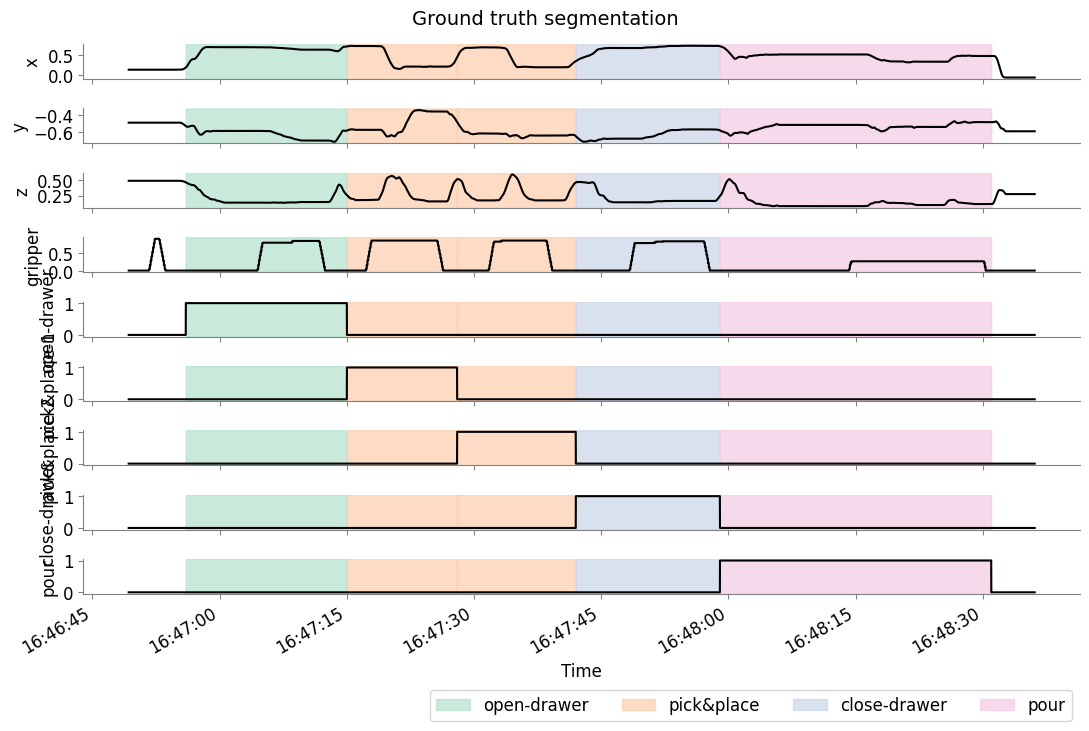

In [24]:
df_labels = list(traj.drop(columns=["timestamp"]).keys())
fig, axes = plt.subplots(
    nrows=len(df_labels), ncols=1, sharex=True, sharey=False, figsize=(11, 7)
)
cmap = mpl.colormaps.get("Pastel2").colors
for idx, ax in enumerate(axes):
    for item in (
        [ax.title, ax.xaxis.label, ax.yaxis.label]
        + ax.get_xticklabels()
        + ax.get_yticklabels()
    ):
        item.set_fontsize(12)

    ax.plot(traj.timestamp, traj[df_labels[idx]], "k")
    ax.set_ylabel(df_labels[idx])
    ax.spines[["right", "top"]].set_visible(False)

    y_low = traj[df_labels[idx]].min()
    y_high = traj[df_labels[idx]].max()
    y_range = np.abs(y_high - y_low) / 2
    y_top = y_high + 0.1 * y_range
    y_bottom = y_low - 0.1 * y_range
    ax.set_ylim(bottom=y_bottom, top=y_top)
    ax.tick_params(color="gray")
    for spine in ax.spines.values():
        spine.set_edgecolor("gray")

    for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
        skill_current = gt_segm_dict["segments"][sect_key]
        if isinstance(skill_current, list):
            for skill_i, skill_val in enumerate(skill_current):
                xs = traj.timestamp[
                    (
                        traj.timestamp
                        > pd.Timestamp(
                            dt.datetime.fromtimestamp(skill_val["ini"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                    & (
                        traj.timestamp
                        < pd.Timestamp(
                            dt.datetime.fromtimestamp(skill_val["end"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                ]  # - dt.timedelta(hours=5)
                if skill_i == 0:
                    ax.fill_between(
                        x=xs,
                        y1=y_bottom,
                        y2=y_top,
                        color=cmap[sect_i],
                        alpha=0.7,
                        # transform=ax.get_xaxis_transform(),
                        label=sect_key,
                    )
                else:
                    ax.fill_between(
                        x=xs,
                        y1=y_bottom,
                        y2=y_top,
                        color=cmap[sect_i],
                        alpha=0.7,
                        # transform=ax.get_xaxis_transform(),
                    )
        elif isinstance(sect_dict_current, dict):
            xs = traj.timestamp[
                (
                    traj.timestamp
                    > pd.Timestamp(
                        dt.datetime.fromtimestamp(skill_current["ini"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
                & (
                    traj.timestamp
                    < pd.Timestamp(
                        dt.datetime.fromtimestamp(skill_current["end"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
            ]  # - dt.timedelta(hours=5)
            ax.fill_between(
                x=xs,
                y1=y_bottom,
                y2=y_top,
                color=cmap[sect_i],
                alpha=0.7,
                # transform=ax.get_xaxis_transform(),
                label=sect_key,
            )
        else:
            raise ValueError("Unexpected value in ground truth JSON file")

axes[-1].set_xlabel("Time")
fig.suptitle("Ground truth segmentation", fontsize=14)
fig.autofmt_xdate()
fig.tight_layout()
axes[-1].legend(bbox_to_anchor=(1, -2.5), ncol=nsegments, fontsize=12)
plt.show()

## Segmentation

### Hyperparameters

In [25]:
# downsampling_factor = 200
resample_num = 2**8
# resample_num = 2**7
print(f"Resampling to {resample_num} data points")
# smoothing = 0.1

Resampling to 256 data points


In [26]:
# what_segments = "HigherLevel"
# # what_segments = "LowerLevel"

labels = gt_segm_dict["segments"].keys()
labels

dict_keys(['open-drawer', 'pick&place', 'close-drawer', 'pour'])

### Preprocessing

In [27]:
X = traj.drop(columns=["timestamp"])
X

,x,y,z,gripper,open-drawer,pick&place-1,pick&place-2,close-drawer,pour
0,0.133347,-0.491981,0.488070,0.01,0.0,0.0,0.0,0.0,0.0
1,0.133354,-0.491975,0.488080,0.01,0.0,0.0,0.0,0.0,0.0
2,0.133358,-0.491972,0.488044,0.01,0.0,0.0,0.0,0.0,0.0
3,0.133351,-0.491997,0.488007,0.01,0.0,0.0,0.0,0.0,0.0
4,0.133328,-0.491981,0.488071,0.01,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
53132,-0.061511,-0.594210,0.273193,0.01,0.0,0.0,0.0,0.0,0.0
53133,-0.061486,-0.594203,0.273203,0.01,0.0,0.0,0.0,0.0,0.0
53134,-0.061480,-0.594227,0.273175,0.01,0.0,0.0,0.0,0.0,0.0
53135,-0.061488,-0.594235,0.273185,0.01,0.0,0.0,0.0,0.0,0.0


In [28]:
def smooth_traj(traj, nb_points=256):
    new_index = np.linspace(start=traj.index.start, stop=traj.index.stop, num=nb_points)
    for idx, col in enumerate(traj.columns):
        if idx == 0:
            traj_smooth = pd.DataFrame(
                {
                    col: make_splrep(x=traj.index, y=traj[col])(new_index),
                }
            )
        else:
            traj_smooth[col] = make_splrep(traj.index, traj[col])(new_index)
    return traj_smooth

In [29]:
# # X_down = signal.decimate(x=X_filtered, q=downsampling_factor, axis=0)
# X_down = signal.resample(x=X, num=resample_num, axis=0)
# X_down = smooth_traj(traj=X, nb_points=resample_num, smoothing=smoothing)
X_down = smooth_traj(traj=X, nb_points=resample_num)
X_down.shape

(256, 9)

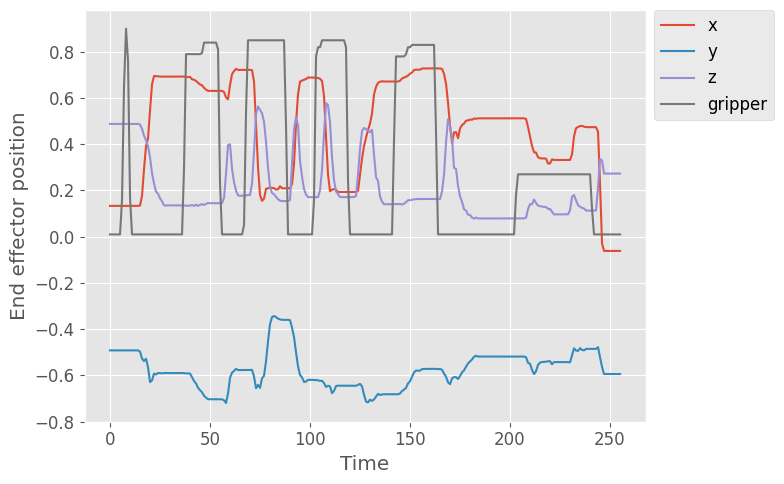

In [30]:
with plt.style.context("ggplot_perso.mplstyle"):
    # with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(8, 5))
    # cmap = mpl.colormaps.get("tab10").colors
    ax.plot(X_down.index, X_down.x, label="x")  # , color=cmap[0])
    ax.plot(X_down.index, X_down.y, label="y")  # , color=cmap[1])
    ax.plot(X_down.index, X_down.z, label="z")  # , color=cmap[2])
    ax.plot(X_down.index, X_down.gripper, label="gripper")  # , color=cmap[3])
    ax.set_xlabel("Time")
    ax.set_ylabel("End effector position")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    # fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

In [31]:
minmaxscaler = MinMaxScaler(feature_range=(0, 1))
X_down_scaled = minmaxscaler.fit_transform(X_down)
X_down_scaled

array([[2.46604807e-001, 6.04815557e-001, 8.19985491e-001, ...,
        6.05450620e-107, 8.79801715e-050, 4.91038945e-072],
       [2.46619969e-001, 6.04837214e-001, 8.19987706e-001, ...,
        6.05450620e-107, 8.79801715e-050, 4.91038945e-072],
       [2.46598603e-001, 6.04822760e-001, 8.19935497e-001, ...,
        6.05450620e-107, 8.79801715e-050, 4.91038945e-072],
       ...,
       [6.10680407e-005, 3.33132549e-001, 3.89892417e-001, ...,
        6.05450620e-107, 8.79801715e-050, 4.91038945e-072],
       [5.34433755e-005, 3.33155138e-001, 3.89864766e-001, ...,
        6.05450620e-107, 8.79801715e-050, 4.91038945e-072],
       [5.46715339e-005, 3.33152735e-001, 3.89845601e-001, ...,
        6.05450620e-107, 8.79801715e-050, 4.91038945e-072]],
      shape=(256, 9))

### Change Point Dectection

In [32]:
# if what_segments == "HigherLevel":
#     # Higher level change points
#     # penalty = 125
#     penalty = 9
#     true_chg_pts_iso = [segm["end"] for segm in gt_segm_dict[what_segments].values()]

penalty = 5
true_chg_pts_iso = []
for skill in gt_segm_dict["segments"].values():
    if isinstance(skill, list):
        for segm in skill:
            true_chg_pts_iso.append(segm["end"])
    elif isinstance(skill, dict):
        true_chg_pts_iso.append(skill["end"])

    else:
        raise ValueError("Unexpected value in ground truth JSON file")

true_chg_pts_iso

[1769723235, 1769723248, 1769723262, 1769723279, 1769723311]

In [33]:
true_chg_pts = np.empty_like(true_chg_pts_iso) * np.nan
true_chg_pts

array([nan, nan, nan, nan, nan])

In [34]:
for idx in range(len(true_chg_pts)):
    true_chg_pts[idx] = traj[
        traj.timestamp
        >= pd.Timestamp(
            dt.datetime.fromtimestamp(
                true_chg_pts_iso[idx]
            ),  # - dt.timedelta(hours=1),
            tz="EST",
        )
    ].index[0]
true_chg_pts

array([12833., 19327., 26280., 34715., 50583.])

In [35]:
true_chg_pts_resampled = [
    round(item * resample_num / X.index.stop) for item in true_chg_pts
]
true_chg_pts_resampled

[62, 93, 127, 167, 244]

In [36]:
# detection
algo = rpt.Pelt(model="rbf").fit(X_down_scaled)
# algo = rpt.KernelCPD(kernel="rbf").fit(X_down_scaled)
# algo = rpt.KernelCPD(kernel="cosine").fit(X_scaled)
computed_chg_pts = algo.predict(pen=penalty)
print(computed_chg_pts)

[20, 60, 95, 130, 165, 245, 256]


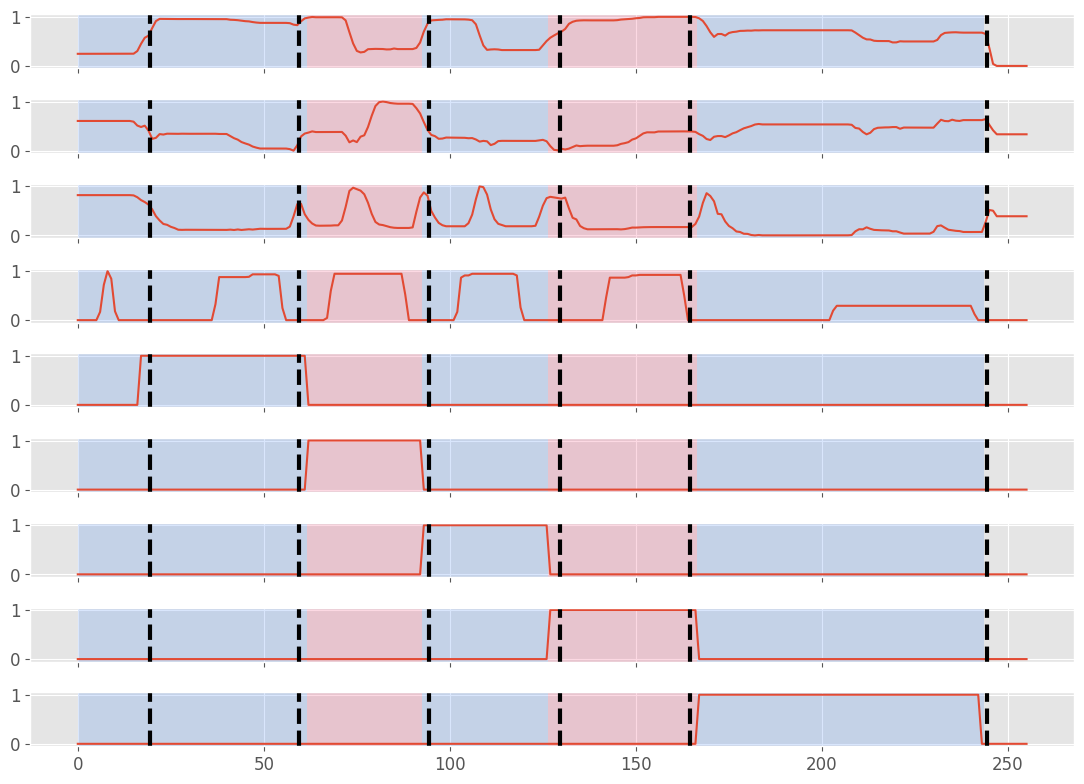

In [37]:
# display
with plt.style.context("ggplot_perso.mplstyle"):
    # rpt.display(minmaxscaler.inverse_transform(X_down_scaled), bkps, result)
    rpt.display(
        signal=X_down_scaled,
        true_chg_pts=true_chg_pts_resampled,
        computed_chg_pts=computed_chg_pts,
        figsize=(11, 8),
    )
    plt.show()

In [38]:
# chg_pts_all = np.concat([[0], computed_chg_pts])
chg_pts_all = computed_chg_pts[:-1]
chg_pts_all

[20, 60, 95, 130, 165, 245]

## Build skills library

In [39]:
### Resample segments to the same length
chg_pts_conv_ori = np.array(
    [int(round(item * len(traj) / resample_num)) for item in chg_pts_all]
)
chg_pts_conv_ori

array([ 4151, 12454, 19719, 26984, 34248, 50854])

In [40]:
similarity_threshold = 0.4

In [41]:
# demos = []
# for seg_i, seg_v in enumerate(chg_pts_all[:-1]):
#     # ts_segm = np.arange(start=0, stop=chg_pts_all[seg_i + 1] - chg_pts_all[seg_i])
#     pos_segm = X_down_scaled[chg_pts_all[seg_i] : chg_pts_all[seg_i + 1], 0:4]
#     # demos.append(np.concat((ts_segm[:, np.newaxis], pos_segm), axis=1))
#     print(pos_segm.shape)
#     demos.append(pos_segm)

In [42]:
def resample_array(array, nb_points=256):
    ori_index = np.arange(array.shape[0])
    new_index = np.linspace(start=0, stop=array.shape[0], num=nb_points)
    arr_resampled = np.ones((nb_points, array.shape[1])) * np.nan
    for colidx, _ in enumerate(range(array.shape[1])):
        arr_resampled[:, colidx] = make_splrep(ori_index, array[:, colidx])(new_index)
    return arr_resampled

In [43]:
demos = []
for seg_i, seg_v in enumerate(chg_pts_conv_ori[:-1]):
    pos_segm = X.iloc[
        chg_pts_conv_ori[seg_i] : chg_pts_conv_ori[seg_i + 1], 0:4
    ].to_numpy()
    pos_segm_resampled = resample_array(pos_segm, nb_points=resample_num)
    print(
        f"Original shape: {pos_segm.shape} - resampled shape: {pos_segm_resampled.shape}"
    )
    demos.append(pos_segm_resampled)

Original shape: (8303, 4) - resampled shape: (256, 4)
Original shape: (7265, 4) - resampled shape: (256, 4)
Original shape: (7265, 4) - resampled shape: (256, 4)
Original shape: (7264, 4) - resampled shape: (256, 4)
Original shape: (16606, 4) - resampled shape: (256, 4)


In [44]:
lib_path = Path("lib.h5")
if lib_path.exists():
    lib_path.unlink()
skills_lib = MP_Library(metric=COS_metric, threshold=similarity_threshold, debug=True)
for demo_i in demos:
    skills_lib.add_primitive(demo_i)
skills_lib.display()
with plt.style.context("ggplot_perso.mplstyle"):
    skills_lib.plot()
    skills_lib.plot_separate()
skills_lib.save_h5(lib_path)

Class not matched, new class: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.508
Class not matched, new class: 'Skill_1'
Class: 'Skill_0' - Similarity: 0.476
Class: 'Skill_1' - Similarity: 0.324
Class matched: 'Skill_1'
Class: 'Skill_0' - Similarity: 0.489
Class: 'Skill_1' - Similarity: 0.468
Class not matched, new class: 'Skill_3'
Class: 'Skill_0' - Similarity: 0.489
Class: 'Skill_1' - Similarity: 0.515
Class: 'Skill_3' - Similarity: 0.488
Class not matched, new class: 'Skill_4'
------------------
--- MP_Library ---
------------------
+ Skill_0: 1
+ Skill_1: 2
+ Skill_3: 1
+ Skill_4: 1
------------------
Plotting not yet implemented for more than 2 dimensions!
Plotting not yet implemented for more than 2 dimensions!


In [45]:
pprint(skills_lib.library)

{'Skill_0': [array([[ 0.53650199, -0.62573961,  0.34370456,  0.01      ],
       [ 0.55789687, -0.63150809,  0.34062382,  0.01      ],
       [ 0.579445  , -0.63417925,  0.33221609,  0.01      ],
       ...,
       [ 0.60920572, -0.65091615,  0.42663417,  0.01      ],
       [ 0.62081763, -0.64074079,  0.4235153 ,  0.01      ],
       [ 0.63473842, -0.62944284,  0.41568491,  0.01      ]],
      shape=(256, 4))],
 'Skill_1': [array([[ 0.63454404, -0.62940016,  0.41623065,  0.01      ],
       [ 0.64747575, -0.61870132,  0.40743212,  0.01      ],
       [ 0.66093551, -0.60767864,  0.39627265,  0.01      ],
       ...,
       [ 0.6396692 , -0.58258617,  0.44121133,  0.01      ],
       [ 0.64708118, -0.58985388,  0.41846794,  0.01      ],
       [ 0.6546569 , -0.59462955,  0.39331437,  0.01      ]],
      shape=(256, 4)),
             array([[ 0.65504047, -0.5943595 ,  0.39300128,  0.01      ],
       [ 0.66266684, -0.59690715,  0.36562324,  0.01      ],
       [ 0.66822687, -0.5982666 , 

## LfD

In [46]:
execution_time = 1.0

In [47]:
idx = 0
ts_segm = np.arange(chg_pts_all[idx], chg_pts_all[idx + 1])
ts_segm

array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59])

In [48]:
pos_segm = X_down_scaled[chg_pts_all[idx] : chg_pts_all[idx + 1], 0:3]
pos_segm.shape

(40, 3)

In [49]:
n_dims = pos_segm.shape[1]

In [50]:
n_nodes = 35
stretch = 0.001
bend = 0.001
weighting = "uniform"
downsampling = "distance"

Constraints:
[[20.          0.77046212  0.24043661  0.52926857]
 [60.          0.90934435  0.28923487  0.64358884]]
Start of learned trajectory: [20.00348311  0.7708301   0.24056876  0.52885838]
End of learned trajectory: [59.99774664  0.90875453  0.28764426  0.64300781]
Constraints:
[[60.          0.90934435  0.28923487  0.64358884]
 [95.          0.92701582  0.32107293  0.49783422]]
Start of learned trajectory: [60.00231344  0.9094657   0.28935836  0.64313496]
End of learned trajectory: [94.99880452  0.92629004  0.32203318  0.50029563]
Constraints:
[[9.50000000e+01 9.27015823e-01 3.21072928e-01 4.97834215e-01]
 [1.30000000e+02 6.97672597e-01 3.83015417e-02 7.48591102e-01]]
Start of learned trajectory: [95.00350227  0.92703396  0.32095236  0.49740356]
End of learned trajectory: [1.29998805e+02 6.97351335e-01 3.80794426e-02 7.48704936e-01]
Constraints:
[[1.30000000e+02 6.97672597e-01 3.83015417e-02 7.48591102e-01]
 [1.65000000e+02 9.99081369e-01 3.90177785e-01 1.69452214e-01]]
Start of

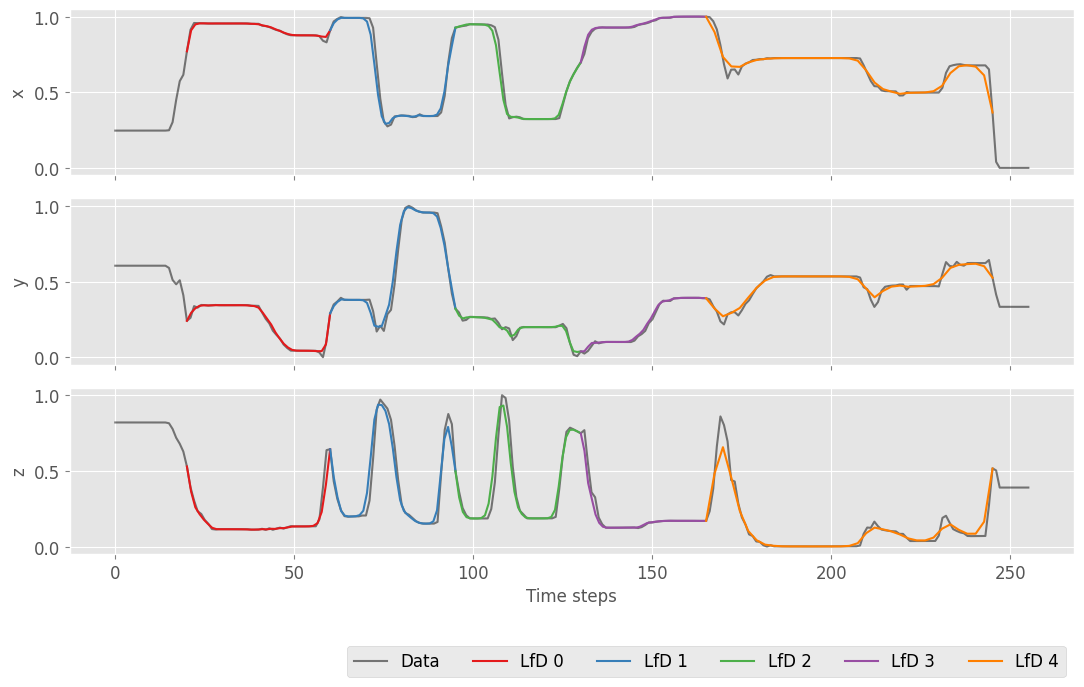

In [51]:
with plt.style.context("ggplot_perso.mplstyle"):
    fig, axes = plt.subplots(
        nrows=pos_segm.shape[1], ncols=1, sharex=True, figsize=(11, 7)
    )
    cmap = mpl.colormaps.get("Set1").colors
    plt_labels = traj.columns[0:3]
    ts = np.arange(stop=X_down_scaled.shape[0])
    for axi, axv in enumerate(axes):
        for item in (
            [axv.title, axv.xaxis.label, axv.yaxis.label]
            + axv.get_xticklabels()
            + axv.get_yticklabels()
        ):
            item.set_fontsize(12)
        axv.plot(X_down_scaled[:, axi], color="k", label="Data", alpha=0.5)
        axv.set_ylabel(plt_labels[axi])
        axv.tick_params(color="gray")

    # chg_pts_all[-1] = chg_pts_all[-1] - 1
    for seg_i, seg_v in enumerate(chg_pts_all[:-1]):
        ts_segm_ref = np.linspace(
            start=chg_pts_all[seg_i], stop=chg_pts_all[seg_i + 1], num=n_nodes
        )
        pos_segm = X_down_scaled[chg_pts_all[seg_i] : chg_pts_all[seg_i + 1], 0:3]
        # ts_elmap = np.arange(pos_segm.shape[0])[:, np.newaxis]
        ts_elmap = np.linspace(
            start=chg_pts_all[seg_i], stop=chg_pts_all[seg_i + 1], num=pos_segm.shape[0]
        )[:, np.newaxis]
        traj_to_learn = np.concat((ts_elmap, pos_segm), axis=1)

        elmap = ElmapEM(
            [traj_to_learn],
            n=n_nodes,
            weighting=weighting,
            downsampling=downsampling,
            stretch=stretch,
            bend=bend,
        )
        # constraints = X_down_scaled[[chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], 0:3]
        constraints = np.hstack(
            (
                np.array([ts_elmap[0], ts_elmap[-1]]),
                X_down_scaled[[chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], 0:3],
            )
        )
        print(f"Constraints:\n{constraints}")
        new_traj = elmap.optimize_map(
            consts=constraints,
            inds=[0, n_nodes - 1],
        )
        new_traj_end = new_traj[:, 1:]
        print(f"Start of learned trajectory: {new_traj[0]}")
        print(f"End of learned trajectory: {new_traj[-1]}")

        for axi, axv in enumerate(axes):
            axv.plot(
                ts_segm_ref,
                new_traj_end[:, axi],
                color=cmap[seg_i],
                label=f"LfD {seg_i}",
            )

    axes[-1].set_xlabel("Time steps")
    axes[-1].legend(bbox_to_anchor=(1, -0.5), ncol=nsegments + 1, fontsize=12)
    fig.tight_layout()
    plt.show()